# Beta-VAE arch x beta sweep (exploration + diagnostics)

Joint sweep over `(base_channels, depth, beta)` at fixed `latent_dim=16`
(Stage 1, 60 configs), then an optional `(lr, weight_decay)` sweep at a
user-chosen Stage-1 config (Stage 2, 9 configs). Every config is scored by
**purged blocked cross-validation** (`make_blocked_cv`): the held-out test
block (D-O event 8 plus padding) is excluded from all folds, and each metric
is the mean across folds. **No automatic winner selection and no checkpoint
persistence**: this notebook produces diagnostics; you read the tables, pick
the architecture, and copy its config plus `mean_best_epoch` into
`05_vae_sweep_winner.ipynb`.

Sweep figures: Bousquet Fig 3 / Fig 5 replicas (on val), a base x depth recon
overview, and a per-dim KL collapse heatmap across all 60 configs to spot
dim-level posterior collapse at a glance.

In [34]:
from __future__ import annotations

import os
import sys
from pathlib import Path

# Anchor to the repo root so paleoreco imports and relative file paths
# resolve regardless of where Jupyter was launched from.
REPO_ROOT = os.path.abspath("..")
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader

from paleoreco.data import (
    PaleoFieldDataset,
    apply_anomaly,
    build_prior_cube,
    compute_zscore_stats,
)
from paleoreco.data.splits import make_blocked_cv
from paleoreco.training.cv import cross_validate, pool_indices
from paleoreco.models.autoencoder import (
    ConvAE,
    ConvBetaVAE,
    count_parameters,
)
from paleoreco.training.trainer_vae import train as train_vae
from paleoreco.training.trainer_ae import set_seed
from paleoreco.eval.ae import reconstruct_split
from paleoreco.eval.vae import (
    compute_vae_diagnostics,
    reconstruct_split_vae,
)
from paleoreco.eval.shared import compute_split_metrics, latent_tidiness

plt.rcParams["figure.dpi"] = 110

In [35]:
SEED = 42
LATENT_DIM = 32
MAX_EPOCHS = 250
PATIENCE = 25
BATCH_SIZE = 32
KL_WARMUP_EPOCHS = 30
LOGVAR_CLAMP = (-10.0, 10.0)

FOLD_YEARS = 4000     # ~5 purged blocked CV folds over the non-test pool

# Stage 1: capacity x beta at v1.5-AE Stage-2 optimiser defaults.
BASE_CHANNELS = (8, 16, 32, 64)
DEPTHS = (2, 3, 4)
BETAS = (1e-5, 1e-4, 1e-3, 1e-2, 1e-1)
LR_STAGE1 = 3e-4
WD_STAGE1 = 1e-3

# Stage 2: optimiser grid at a user-chosen (base, depth, beta). Set
# STAGE2_TARGET below to enable; leave as None to skip Stage 2.
LRS = (3e-5, 1e-5, 3e-4, 1e-4)
WDS = (1e-5, 1e-4, 1e-3)
STAGE2_TARGET: tuple[int, int, float] | None = None

# Per-dim health threshold for the selection helper: a dim with KL >
# DIM_ALIVE_KL is treated as carrying information (not collapsed onto
# the prior). 1.0 nat is the convention from the wider VAE literature.
DIM_ALIVE_KL = 1.0

OUT_DIR = Path(REPO_ROOT) / "outputs"
CSV_DIR = OUT_DIR / "csvs" / "04_vae_sweep"
FIG_DIR = OUT_DIR / "figures" / "04_vae_sweep"
STAGE1_CSV = CSV_DIR / "stage1.csv"
STAGE2_CSV = CSV_DIR / "stage2.csv"
AE_WINNER_PT = OUT_DIR / "checkpoints" / "02_ae_arch_sweep" / "ae_sweep_winner.pt"

for d in (OUT_DIR, CSV_DIR, FIG_DIR):
    d.mkdir(parents=True, exist_ok=True)

## Data and cross-validation folds

In [36]:
data = build_prior_cube(
    prior_csv=os.path.join(REPO_ROOT, "data/Prior.csv"),
    cache_path=os.path.join(REPO_ROOT, "data/cache/prior_cube.npz"),
)
cube = data["cube"]
ages = data["ages"]
lats = data["lats"]
lons = data["lons"]
valid = data["valid"]
N_AGES = len(ages)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"cube: {cube.shape}  ages: [{ages.min()}, {ages.max()}] yr BP")
print(f"device: {device}")

# Purged blocked CV: the test block (event 8 + padding) is held out of every
# fold; cross_validate refits z-score stats per fold on its train ages only.
cv = make_blocked_cv(ages, fold_years=FOLD_YEARS)
test_idx = cv["test"]
pool = pool_indices(cv["folds"])
print(
    f"{len(cv['folds'])} folds; pool={pool.size} ages; "
    f"test={test_idx.size} ages [{ages[test_idx].min()}, {ages[test_idx].max()}] yr BP"
)

# Pool-stats test set for the AE reference: the AE winner from 03 was refit on
# this same pool, so its training stats match these and the test block is the
# block neither model trained on.
pool_stats = compute_zscore_stats(cube, train_age_indices=pool, valid=valid)
cube_anom_pool = apply_anomaly(cube, pool_stats)
mask = pool_stats["safe_valid"]
test_ds = PaleoFieldDataset(cube_anom_pool, mask, test_idx)
print(f"safe_valid cells: {int(mask.sum())} / {mask.size}")

cube: (804, 2, 32, 64)  ages: [29100, 49175] yr BP
device: cuda
5 folds; pool=644 ages; test=80 ages [37325, 39300] yr BP
safe_valid cells: 2048 / 2048


## AE reference

Evaluate the AE sweep winner (refit on the same non-test pool in notebook 02)
on the held-out test block. It serves as a horizontal reference on the Bousquet
Fig 3 replica below; the VAE configs there are scored by CV-mean val, so this
is an approximate, not exactly co-located, reference line.

In [37]:
ae_ckpt = torch.load(str(AE_WINNER_PT), map_location="cpu", weights_only=False)
ae_model = ConvAE(**ae_ckpt["config"])
ae_model.load_state_dict(ae_ckpt["state_dict"])
ae_model = ae_model.to(device)
ae_truth, ae_pred = reconstruct_split(ae_model, test_ds, device=device, batch_size=BATCH_SIZE)
ae_test = compute_split_metrics(ae_truth, ae_pred, mask)
AE_TEST_E_D = ae_test["E_d"]
AE_TEST_MSE = ae_test["mse"]
print(f"AE reference (d={ae_ckpt['config']['latent_dim']}, base={ae_ckpt['config']['base_channels']}, depth={ae_ckpt['config']['depth']}):")
print(f"  test_mse={AE_TEST_MSE:.4f}  test_E_d={AE_TEST_E_D:.4f}")

AE reference (d=32, base=32, depth=2):
  test_mse=0.0572  test_E_d=0.9622


## Per-config training helper

Cross-validates one VAE config over the non-test folds and returns CV mean/std
of its val metrics, VAE diagnostics, `latent_tidiness`, the Bousquet `<sigma>`
and `<D>` (on val), and the mean best-epoch. The held-out test block never
enters the sweep.

In [38]:
def train_one_config_vae(base_channels, depth, beta, lr, weight_decay):
    """Cross-validate one VAE config; return CV mean/std metrics + diagnostics.

    cross_validate refits z-score stats per fold; the closure trains a fresh
    ConvBetaVAE, early-stops on the fold val, and reports reconstruction metrics,
    VAE diagnostics, latent_tidiness, and the Bousquet <sigma>/<D> on the fold
    val. Returned keys carry the CSV column names so the loop just pulls the
    cross_validate ``*_mean`` aggregate.
    """
    def fit_eval(train_loader, val_loader, fold_mask, fold_stats, val_ds):
        set_seed(SEED)
        model = ConvBetaVAE(
            latent_dim=LATENT_DIM, base_channels=base_channels,
            depth=depth, logvar_clamp=LOGVAR_CLAMP,
        )
        out = train_vae(
            model, train_loader, val_loader,
            mask=fold_mask,
            beta=beta, kl_warmup_epochs=KL_WARMUP_EPOCHS,
            lr=lr, weight_decay=weight_decay,
            max_epochs=MAX_EPOCHS, patience=PATIENCE,
            device=device, seed=SEED, verbose=False, progress=False,
        )
        model.load_state_dict(out["best_state_dict"])
        truth, pred, mu, lv = reconstruct_split_vae(
            model, val_ds, device=device, batch_size=BATCH_SIZE,
        )
        m = compute_split_metrics(truth, pred, fold_mask)
        diag = compute_vae_diagnostics(mu, lv)
        tidy = latent_tidiness(mu)
        # Bousquet Fig 5 on val: <sigma> = mean posterior std; <D> = mean
        # pairwise L2 distance between mu vectors.
        sigma_mean = float(np.exp(0.5 * lv).mean())
        n = mu.shape[0]
        iu = np.triu_indices(n, k=1)
        pair = np.sqrt(((mu[:, None, :] - mu[None, :, :]) ** 2).sum(-1))
        pair_dist_mean = float(pair[iu].mean()) if iu[0].size else float("nan")

        row = {
            "val_mse":              m["mse"],
            "val_rmse":             m["rmse"],
            "val_rrmse":              m["rrmse"],
            "val_r_squared":          m["r_squared"],
            "val_E_d":                m["E_d"],
            "val_kl_total":           diag["kl_total"],
            "val_kl_per_dim_max":     float(diag["kl_per_dim"].max()),
            "val_kl_per_dim_min":     float(diag["kl_per_dim"].min()),
            "val_total_loss":         out["best_val_loss"],
            "val_mu_norm":            diag["mu_norm"],
            "val_post_cov_diag_mean": diag["post_cov_diag_mean"],
            "val_sigma_mean":         sigma_mean,
            "val_pair_dist_mean":     pair_dist_mean,
            **tidy,
            "best_epoch":     out["best_epoch"],
            "epochs_trained": out["epochs_trained"],
            "n_params":       count_parameters(model),
        }
        for j, kl_j in enumerate(diag["kl_per_dim"]):
            row[f"val_kl_dim_{j}"] = float(kl_j)
        return row

    return cross_validate(cube, valid, cv["folds"], fit_eval, batch_size=BATCH_SIZE)

## Stage 1: capacity x beta sweep (60 configs)

All at `lr=LR_STAGE1`, `weight_decay=WD_STAGE1`. Joint over `(base, depth,
beta)` so the arch x beta interaction Bousquet flags (his Fig 3c) is
visible. CSV row written incrementally so a kernel crash on run k
preserves rows 1..k-1.


In [6]:
stage1_rows: list[dict] = []
stage1_configs = [
    (b, d, beta)
    for b in BASE_CHANNELS
    for d in DEPTHS
    for beta in BETAS
]

for i, (base, depth, beta) in enumerate(stage1_configs, start=1):
    print(f"\n[Stage 1 {i:>2}/{len(stage1_configs)}] base={base}  depth={depth}  beta={beta:.0e}")
    agg = train_one_config_vae(base, depth, beta, LR_STAGE1, WD_STAGE1)
    row = {
        "base_channels":          base,
        "depth":                  depth,
        "beta":                   beta,
        "val_mse":              agg["val_mse_mean"],
        "val_mse_std":          agg["val_mse_std"],
        "val_rmse":             agg["val_rmse_mean"],
        "val_rrmse":              agg["val_rrmse_mean"],
        "val_r_squared":          agg["val_r_squared_mean"],
        "val_E_d":                agg["val_E_d_mean"],
        "val_kl_total":           agg["val_kl_total_mean"],
        "val_kl_per_dim_max":     agg["val_kl_per_dim_max_mean"],
        "val_kl_per_dim_min":     agg["val_kl_per_dim_min_mean"],
        "val_total_loss":         agg["val_total_loss_mean"],
        "val_mu_norm":            agg["val_mu_norm_mean"],
        "val_post_cov_diag_mean": agg["val_post_cov_diag_mean_mean"],
        "val_sigma_mean":         agg["val_sigma_mean_mean"],
        "val_pair_dist_mean":     agg["val_pair_dist_mean_mean"],
        "decorr_offdiag":         agg["decorr_offdiag_mean"],
        "cov_cond":               agg["cov_cond_mean"],
        "effective_rank":         agg["effective_rank_mean"],
        "dim_var_cv":             agg["dim_var_cv_mean"],
        "n_params":               agg["n_params_mean"],
        "mean_best_epoch":        agg["best_epoch_mean"],
        "n_folds":                agg["n_folds"],
    }
    # Per-dim KL: CV-mean of each dim's KL, so the heatmap and active-dim count
    # work unchanged on the mean across folds.
    for j in range(LATENT_DIM):
        row[f"val_kl_dim_{j}"] = agg[f"val_kl_dim_{j}_mean"]
    stage1_rows.append(row)
    pd.DataFrame(stage1_rows).to_csv(STAGE1_CSV, index=False)

    print(
        f"  val_mse={agg['val_mse_mean']:.4f}  E_d={agg['val_E_d_mean']:.3f}  "
        f"KL_total={agg['val_kl_total_mean']:.3f}  mu_norm={agg['val_mu_norm_mean']:.3f}  "
        f"eff_rank={agg['effective_rank_mean']:.1f}  mean_best_epoch={agg['best_epoch_mean']:.0f}"
    )

stage1_df = pd.read_csv(STAGE1_CSV)
print(f"\nStage 1 complete: {len(stage1_df)} rows written to {STAGE1_CSV.relative_to(OUT_DIR.parent)}")


[Stage 1  1/60] base=8  depth=2  beta=1e-05
  val_mse=0.4698  E_d=0.812  KL_total=182.607  mu_norm=9.234  eff_rank=1.4  mean_best_epoch=205

[Stage 1  2/60] base=8  depth=2  beta=1e-04
  val_mse=0.4660  E_d=0.814  KL_total=120.241  mu_norm=5.512  eff_rank=1.6  mean_best_epoch=207

[Stage 1  3/60] base=8  depth=2  beta=1e-03
  val_mse=0.4743  E_d=0.812  KL_total=61.162  mu_norm=4.540  eff_rank=2.5  mean_best_epoch=188

[Stage 1  4/60] base=8  depth=2  beta=1e-02
  val_mse=0.6853  E_d=0.736  KL_total=14.480  mu_norm=3.165  eff_rank=2.1  mean_best_epoch=164

[Stage 1  5/60] base=8  depth=2  beta=1e-01
  val_mse=1.0597  E_d=0.587  KL_total=2.979  mu_norm=1.670  eff_rank=1.3  mean_best_epoch=145

[Stage 1  6/60] base=8  depth=3  beta=1e-05
  val_mse=0.5466  E_d=0.765  KL_total=173.719  mu_norm=9.199  eff_rank=1.5  mean_best_epoch=177

[Stage 1  7/60] base=8  depth=3  beta=1e-04
  val_mse=0.5550  E_d=0.767  KL_total=114.803  mu_norm=5.812  eff_rank=1.7  mean_best_epoch=155

[Stage 1  8/60] 

## Stage 1 figures


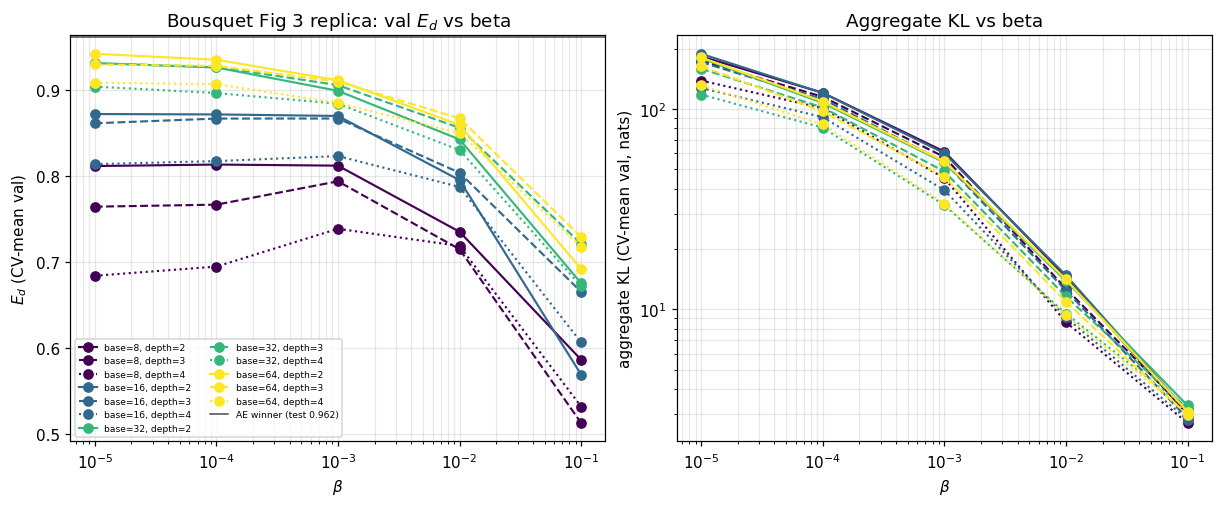

In [7]:
# Bousquet Fig 3 replica: E_d (CV-mean val) vs beta (left), aggregate KL vs beta
# (right), one line per (base, depth). Colour by base, linestyle by depth.
BASE_COLORS = {b: plt.get_cmap("viridis")(i / max(len(BASE_CHANNELS) - 1, 1))
               for i, b in enumerate(BASE_CHANNELS)}
DEPTH_STYLES = {2: "-", 3: "--", 4: ":"}

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), constrained_layout=True)

ax = axes[0]
for base in BASE_CHANNELS:
    for depth in DEPTHS:
        sub = stage1_df[(stage1_df["base_channels"] == base) & (stage1_df["depth"] == depth)]
        sub = sub.sort_values("beta")
        ax.plot(
            sub["beta"], sub["val_E_d"],
            color=BASE_COLORS[base], ls=DEPTH_STYLES[depth], marker="o", lw=1.4,
            label=f"base={base}, depth={depth}",
        )
ax.axhline(AE_TEST_E_D, color="k", lw=1.0, alpha=0.7, label=f"AE winner (test {AE_TEST_E_D:.3f})")
ax.set_xscale("log")
ax.set_xlabel(r"$\beta$")
ax.set_ylabel(r"$E_d$ (CV-mean val)")
ax.set_title("Bousquet Fig 3 replica: val $E_d$ vs beta")
ax.grid(True, alpha=0.3, which="both")
ax.legend(fontsize=6, ncol=2, loc="lower left")

ax = axes[1]
for base in BASE_CHANNELS:
    for depth in DEPTHS:
        sub = stage1_df[(stage1_df["base_channels"] == base) & (stage1_df["depth"] == depth)]
        sub = sub.sort_values("beta")
        ax.plot(
            sub["beta"], sub["val_kl_total"],
            color=BASE_COLORS[base], ls=DEPTH_STYLES[depth], marker="o", lw=1.4,
        )
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"$\beta$")
ax.set_ylabel(r"aggregate KL (CV-mean val, nats)")
ax.set_title("Aggregate KL vs beta")
ax.grid(True, alpha=0.3, which="both")

fig.savefig(FIG_DIR / "stage1_bousquet_fig3.png", bbox_inches="tight", dpi=120)
plt.show()

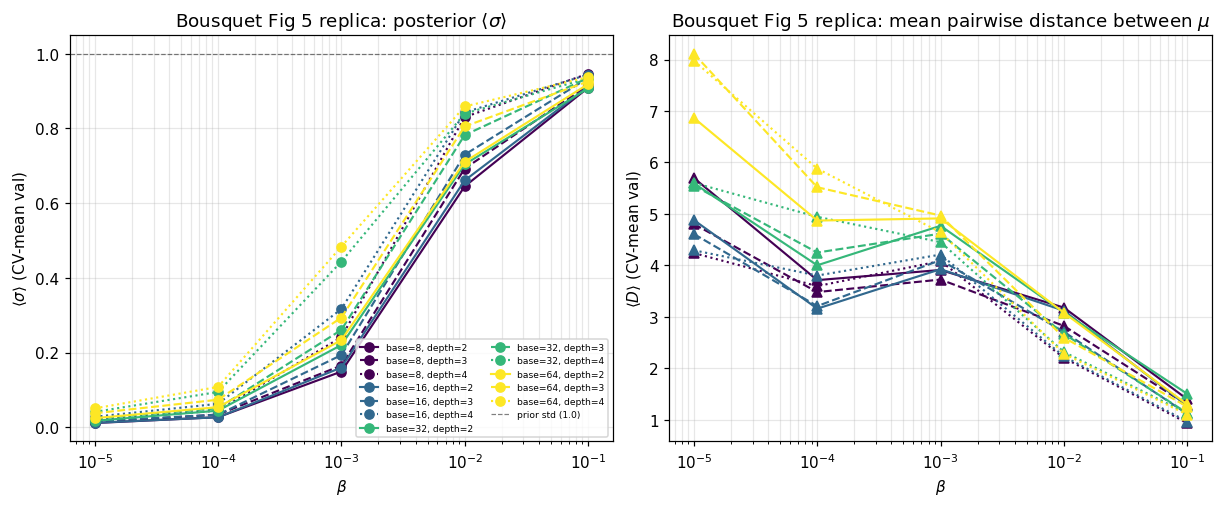

In [8]:
# Bousquet Fig 5 replica (on val): <sigma> = mean of exp(0.5 * logvar);
# <D> = mean pairwise L2 distance between mu vectors. Same colour/style as Fig 3.
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), constrained_layout=True)

ax = axes[0]
for base in BASE_CHANNELS:
    for depth in DEPTHS:
        sub = stage1_df[(stage1_df["base_channels"] == base) & (stage1_df["depth"] == depth)]
        sub = sub.sort_values("beta")
        ax.plot(
            sub["beta"], sub["val_sigma_mean"],
            color=BASE_COLORS[base], ls=DEPTH_STYLES[depth], marker="o", lw=1.4,
            label=f"base={base}, depth={depth}",
        )
ax.axhline(1.0, color="k", lw=0.8, alpha=0.5, ls="--", label="prior std (1.0)")
ax.set_xscale("log")
ax.set_xlabel(r"$\beta$")
ax.set_ylabel(r"$\langle\sigma\rangle$ (CV-mean val)")
ax.set_title("Bousquet Fig 5 replica: posterior $\\langle\\sigma\\rangle$")
ax.grid(True, alpha=0.3, which="both")
ax.legend(fontsize=6, ncol=2, loc="lower right")

ax = axes[1]
for base in BASE_CHANNELS:
    for depth in DEPTHS:
        sub = stage1_df[(stage1_df["base_channels"] == base) & (stage1_df["depth"] == depth)]
        sub = sub.sort_values("beta")
        ax.plot(
            sub["beta"], sub["val_pair_dist_mean"],
            color=BASE_COLORS[base], ls=DEPTH_STYLES[depth], marker="^", lw=1.4,
        )
ax.set_xscale("log")
ax.set_xlabel(r"$\beta$")
ax.set_ylabel(r"$\langle D\rangle$ (CV-mean val)")
ax.set_title("Bousquet Fig 5 replica: mean pairwise distance between $\\mu$")
ax.grid(True, alpha=0.3, which="both")

fig.savefig(FIG_DIR / "stage1_bousquet_fig5.png", bbox_inches="tight", dpi=120)
plt.show()

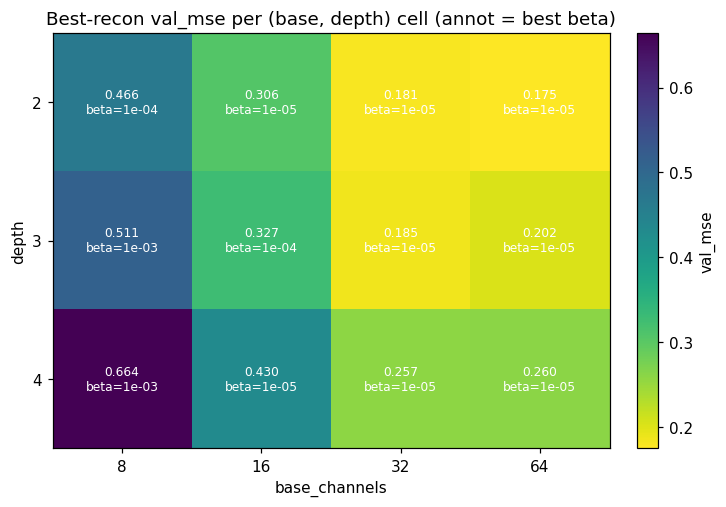

In [9]:
# Stage-1 (base, depth) overview: for each (base, depth) cell, the
# best-recon beta and its val_mse. Exploratory only; not a selection.
overview_rows = []
for base in BASE_CHANNELS:
    for depth in DEPTHS:
        sub = stage1_df[(stage1_df["base_channels"] == base) & (stage1_df["depth"] == depth)]
        best = sub.sort_values("val_mse").iloc[0]
        overview_rows.append({
            "base_channels": base,
            "depth":         depth,
            "best_beta":     float(best["beta"]),
            "val_mse":     float(best["val_mse"]),
        })
overview_df = pd.DataFrame(overview_rows)

grid_mse = overview_df.pivot(index="depth", columns="base_channels", values="val_mse")
grid_beta = overview_df.pivot(index="depth", columns="base_channels", values="best_beta")

fig, ax = plt.subplots(figsize=(6.5, 4.5), constrained_layout=True)
im = ax.imshow(grid_mse.values, aspect="auto", cmap="viridis_r")
ax.set_xticks(range(len(grid_mse.columns)), [f"{b}" for b in grid_mse.columns])
ax.set_yticks(range(len(grid_mse.index)), [f"{d}" for d in grid_mse.index])
ax.set_xlabel("base_channels")
ax.set_ylabel("depth")
ax.set_title("Best-recon val_mse per (base, depth) cell (annot = best beta)")
for i in range(grid_mse.shape[0]):
    for j in range(grid_mse.shape[1]):
        ax.text(
            j, i, f"{grid_mse.values[i, j]:.3f}\nbeta={grid_beta.values[i, j]:.0e}",
            ha="center", va="center", color="w", fontsize=8,
        )
fig.colorbar(im, ax=ax, label="val_mse")
fig.savefig(FIG_DIR / "stage1_heatmap.png", bbox_inches="tight", dpi=120)
plt.show()


### Per-dim KL collapse diagnostic

Heatmap of `KL_k` across all 60 Stage-1 configs and all 16 latent dims.
Rows are sorted by `beta` first (5 horizontal bands), then by
`(base, depth)` within each band. The colormap diverges around the alive
threshold `DIM_ALIVE_KL` (=1.0 nat by default): red cells are collapsed
or near-collapsed dims, green cells are active dims. Use this to spot
configs whose aggregate KL is small only because individual dims have
gone dead.


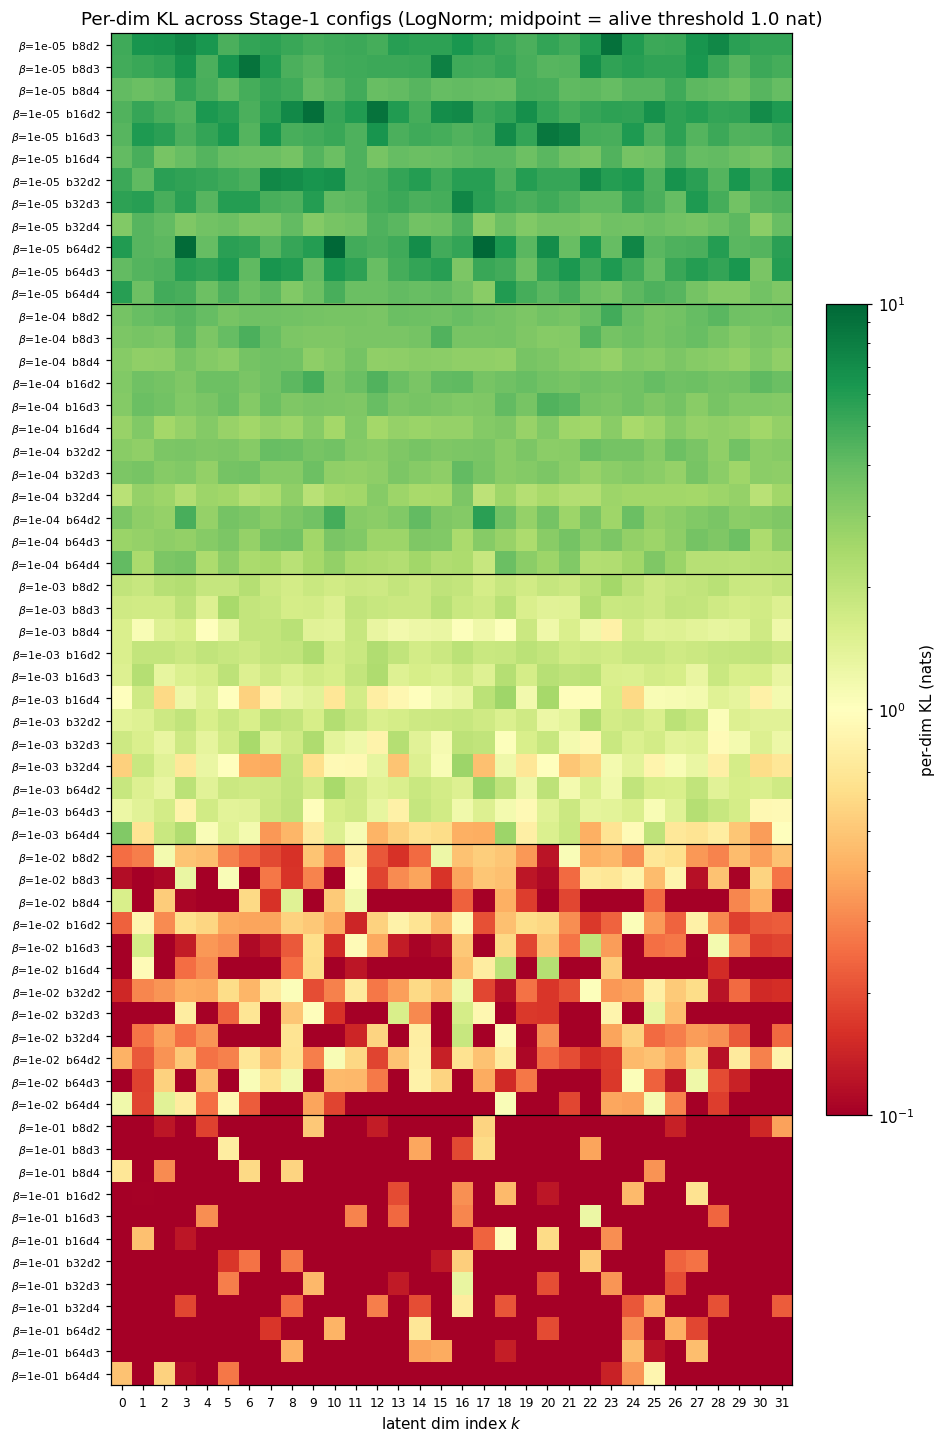

In [10]:
from matplotlib.colors import LogNorm

# Sort by beta then (base, depth) so the heatmap has 5 horizontal bands
# (one per beta), each showing the 12 architectures.
sorted_rows = stage1_df.sort_values(
    ["beta", "base_channels", "depth"]
).reset_index(drop=True)
kl_cols = [f"val_kl_dim_{j}" for j in range(LATENT_DIM)]
kl_matrix = sorted_rows[kl_cols].values  # (60, LATENT_DIM)

# LogNorm centred on the alive threshold: log10(0.1) and log10(10) are
# symmetric around log10(1.0), so the colormap midpoint lands at the
# threshold value DIM_ALIVE_KL.
vmin = max(1e-4, DIM_ALIVE_KL * 0.1)
vmax = DIM_ALIVE_KL * 10
clipped = np.clip(kl_matrix, vmin, vmax)

fig, ax = plt.subplots(figsize=(8.5, 13), constrained_layout=True)
im = ax.imshow(
    clipped, aspect="auto", cmap="RdYlGn",
    norm=LogNorm(vmin=vmin, vmax=vmax),
    interpolation="nearest",
)
ax.set_xticks(range(LATENT_DIM))
ax.set_xticklabels([str(j) for j in range(LATENT_DIM)], fontsize=8)
ax.set_xlabel("latent dim index $k$")

row_labels = [
    f"$\\beta$={r.beta:.0e}  b{r.base_channels}d{r.depth}"
    for r in sorted_rows.itertuples()
]
ax.set_yticks(range(len(sorted_rows)))
ax.set_yticklabels(row_labels, fontsize=7)

# Horizontal separators between beta bands so the structure is obvious.
prev_beta = None
for i, row in enumerate(sorted_rows.itertuples()):
    if prev_beta is not None and row.beta != prev_beta:
        ax.axhline(i - 0.5, color="black", lw=0.8)
    prev_beta = row.beta

ax.set_title(
    f"Per-dim KL across Stage-1 configs (LogNorm; midpoint = "
    f"alive threshold {DIM_ALIVE_KL:.1f} nat)"
)
fig.colorbar(im, ax=ax, label="per-dim KL (nats)", shrink=0.6)
fig.savefig(FIG_DIR / "stage1_per_dim_kl.png", bbox_inches="tight", dpi=120)
plt.show()


## Stage 1 candidate inspection

Three sorts so the manual choice is easy to compare. `n_active_dims`
counts dims with `KL_k > DIM_ALIVE_KL`. The third sort restricts to
configs whose latent is healthy (`n_active_dims >= MIN_ACTIVE_DIMS`),
then ranks by recon; this is usually the most useful view for picking a
balanced winner.


In [11]:
# Threshold for "healthy latent" in the third inspection view. Out of
# LATENT_DIM=16 dims, a config with at least MIN_ACTIVE_DIMS dims above
# the alive threshold is considered structurally healthy.
MIN_ACTIVE_DIMS = 14

kl_cols = [f"val_kl_dim_{j}" for j in range(LATENT_DIM)]
df = stage1_df.copy()
df["n_active_dims"] = (df[kl_cols] > DIM_ALIVE_KL).sum(axis=1)

display_cols = [
    "base_channels", "depth", "beta",
    "val_mse", "val_E_d", "val_kl_total",
    "val_kl_per_dim_min", "n_active_dims",
    "effective_rank", "decorr_offdiag", "cov_cond",
    "val_mu_norm", "n_params", "mean_best_epoch",
]

print("=" * 80)
print("Top 10 by recon (smallest val_mse, ignores collapse):")
print("=" * 80)
print(df.sort_values("val_mse").head(10)[display_cols].to_string(index=False))

print("\n" + "=" * 80)
print("Top 10 by aggregate KL (smallest val_kl_total, ignores recon):")
print("=" * 80)
print(df.sort_values("val_kl_total").head(10)[display_cols].to_string(index=False))

print("\n" + "=" * 80)
print(
    f"Top 10 healthy configs (n_active_dims >= {MIN_ACTIVE_DIMS}), "
    f"ranked by val_mse:"
)
print("=" * 80)
healthy = df[df["n_active_dims"] >= MIN_ACTIVE_DIMS]
if healthy.empty:
    print(
        f"(no configs meet n_active_dims >= {MIN_ACTIVE_DIMS}; "
        f"lower MIN_ACTIVE_DIMS to inspect)"
    )
else:
    print(healthy.sort_values("val_mse").head(10)[display_cols].to_string(index=False))

Top 10 by recon (smallest val_mse, ignores collapse):
 base_channels  depth    beta  val_mse  val_E_d  val_kl_total  val_kl_per_dim_min  n_active_dims  effective_rank  decorr_offdiag     cov_cond  val_mu_norm  n_params  mean_best_epoch
            64      2 0.00001 0.175023 0.942434    180.640253            3.255976             32        2.396151        0.404700 7.176493e+05    10.995644 1758370.0            122.4
            32      2 0.00001 0.180508 0.931626    178.950317            3.653460             32        2.290705        0.469771 1.766410e+04    10.153650  837746.0            185.8
            32      3 0.00001 0.185141 0.931240    158.631097            3.351633             32        2.429489        0.443661 2.487476e+05     9.033576  588466.0            158.6
            64      2 0.00010 0.191326 0.935546    108.721297            2.391370             32        2.785304        0.375071 2.776427e+04     6.644438 1758370.0            108.8
            32      2 0.00010 0.1949

## Optional Stage 2: lr x weight_decay sweep at a user-chosen target

Gated on `STAGE2_TARGET` in the constants cell. Set it to a
`(base, depth, beta)` triple to refine the optimiser hypers at that
config; leave as `None` to skip. Stage 1 uses fixed `LR_STAGE1` and
`WD_STAGE1`, so Stage 2 is the place to confirm those defaults or
adjust them.


In [39]:
# Set to a (base, depth, beta) triple from the Stage-1 tables to refine its
# optimiser hypers; leave None to skip Stage 2.
STAGE2_TARGET: tuple[int, int, float] | None = (64, 2, 1e-3)

In [40]:
if STAGE2_TARGET is None:
    print(
        "Stage 2 skipped. Set STAGE2_TARGET = (base, depth, beta) in the "
        "constants cell and re-run from this cell to refine optimiser hypers."
    )
else:
    BASE_S2, DEPTH_S2, BETA_S2 = STAGE2_TARGET
    print(f"Stage 2 target: base={BASE_S2}, depth={DEPTH_S2}, beta={BETA_S2:.0e}")

    stage2_rows: list[dict] = []
    stage2_configs = [(lr, wd) for lr in LRS for wd in WDS]

    for i, (lr, wd) in enumerate(stage2_configs, start=1):
        print(f"\n[Stage 2 {i}/{len(stage2_configs)}] lr={lr:.0e}  wd={wd:.0e}")
        agg = train_one_config_vae(BASE_S2, DEPTH_S2, BETA_S2, lr, wd)
        row = {
            "lr":                     lr,
            "weight_decay":           wd,
            "val_mse":              agg["val_mse_mean"],
            "val_mse_std":          agg["val_mse_std"],
            "val_rmse":             agg["val_rmse_mean"],
            "val_rrmse":              agg["val_rrmse_mean"],
            "val_r_squared":          agg["val_r_squared_mean"],
            "val_E_d":                agg["val_E_d_mean"],
            "val_kl_total":           agg["val_kl_total_mean"],
            "val_kl_per_dim_max":     agg["val_kl_per_dim_max_mean"],
            "val_kl_per_dim_min":     agg["val_kl_per_dim_min_mean"],
            "val_total_loss":         agg["val_total_loss_mean"],
            "val_mu_norm":            agg["val_mu_norm_mean"],
            "val_post_cov_diag_mean": agg["val_post_cov_diag_mean_mean"],
            "effective_rank":         agg["effective_rank_mean"],
            "decorr_offdiag":         agg["decorr_offdiag_mean"],
            "cov_cond":               agg["cov_cond_mean"],
            "n_params":               agg["n_params_mean"],
            "mean_best_epoch":        agg["best_epoch_mean"],
            "n_folds":                agg["n_folds"],
        }
        for j in range(LATENT_DIM):
            row[f"val_kl_dim_{j}"] = agg[f"val_kl_dim_{j}_mean"]
        stage2_rows.append(row)
        pd.DataFrame(stage2_rows).to_csv(STAGE2_CSV, index=False)

        print(
            f"  val_mse={agg['val_mse_mean']:.4f}  E_d={agg['val_E_d_mean']:.3f}  "
            f"KL_total={agg['val_kl_total_mean']:.3f}  "
            f"mean_best_epoch={agg['best_epoch_mean']:.0f}"
        )

    stage2_df = pd.read_csv(STAGE2_CSV)
    print(f"\nStage 2 complete: {len(stage2_df)} rows written to {STAGE2_CSV.relative_to(OUT_DIR.parent)}")

Stage 2 target: base=64, depth=2, beta=1e-03

[Stage 2 1/12] lr=3e-05  wd=1e-05
  val_mse=0.2932  E_d=0.904  KL_total=59.209  mean_best_epoch=196

[Stage 2 2/12] lr=3e-05  wd=1e-04
  val_mse=0.2932  E_d=0.904  KL_total=59.209  mean_best_epoch=196

[Stage 2 3/12] lr=3e-05  wd=1e-03
  val_mse=0.2932  E_d=0.904  KL_total=59.208  mean_best_epoch=196

[Stage 2 4/12] lr=1e-05  wd=1e-05
  val_mse=0.4422  E_d=0.847  KL_total=62.099  mean_best_epoch=229

[Stage 2 5/12] lr=1e-05  wd=1e-04
  val_mse=0.4422  E_d=0.847  KL_total=62.099  mean_best_epoch=229

[Stage 2 6/12] lr=1e-05  wd=1e-03
  val_mse=0.4422  E_d=0.847  KL_total=62.099  mean_best_epoch=229

[Stage 2 7/12] lr=3e-04  wd=1e-05
  val_mse=0.2667  E_d=0.912  KL_total=54.549  mean_best_epoch=78

[Stage 2 8/12] lr=3e-04  wd=1e-04
  val_mse=0.2670  E_d=0.912  KL_total=54.600  mean_best_epoch=78

[Stage 2 9/12] lr=3e-04  wd=1e-03
  val_mse=0.2668  E_d=0.912  KL_total=54.577  mean_best_epoch=78

[Stage 2 10/12] lr=1e-04  wd=1e-05
  val_mse=0.2

## Stage 2 figure


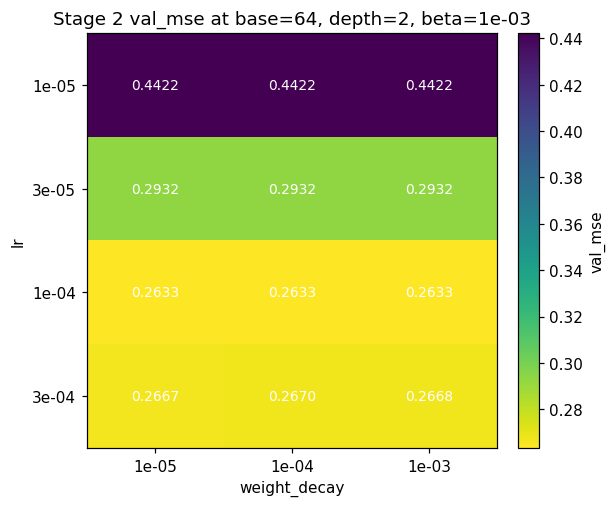

In [41]:
if STAGE2_TARGET is None:
    print("Stage 2 figure skipped (Stage 2 not run).")
else:
    grid = stage2_df.pivot(index="lr", columns="weight_decay", values="val_mse")
    fig, ax = plt.subplots(figsize=(5.5, 4.5), constrained_layout=True)
    im = ax.imshow(grid.values, aspect="auto", cmap="viridis_r")
    ax.set_xticks(range(len(grid.columns)), [f"{w:.0e}" for w in grid.columns])
    ax.set_yticks(range(len(grid.index)),   [f"{l:.0e}" for l in grid.index])
    ax.set_xlabel("weight_decay")
    ax.set_ylabel("lr")
    ax.set_title(
        f"Stage 2 val_mse at base={BASE_S2}, depth={DEPTH_S2}, beta={BETA_S2:.0e}"
    )
    for i in range(grid.shape[0]):
        for j in range(grid.shape[1]):
            ax.text(j, i, f"{grid.values[i, j]:.4f}", ha="center", va="center",
                    color="w", fontsize=9)
    fig.colorbar(im, ax=ax, label="val_mse")
    fig.savefig(FIG_DIR / "stage2_lr_wd_grid.png", bbox_inches="tight", dpi=120)
    plt.show()


## Stage 2 candidate inspection


In [42]:
if STAGE2_TARGET is None:
    print("Stage 2 inspection skipped (Stage 2 not run).")
else:
    stage2_sorted = stage2_df.sort_values("val_mse").reset_index(drop=True)
    print("Stage 2 sorted by val_mse:")
    print(stage2_sorted[[
        "lr", "weight_decay",
        "val_mse", "val_E_d", "val_kl_total",
        "val_kl_per_dim_min", "effective_rank", "mean_best_epoch",
    ]].to_string(index=False))

Stage 2 sorted by val_mse:
     lr  weight_decay  val_mse  val_E_d  val_kl_total  val_kl_per_dim_min  effective_rank  mean_best_epoch
0.00010       0.00100 0.263296 0.916793     57.044356            1.013605        3.105771            137.6
0.00010       0.00001 0.263306 0.916789     57.040923            1.013538        3.105659            137.6
0.00010       0.00010 0.263310 0.916790     57.040912            1.013599        3.105661            137.6
0.00030       0.00001 0.266673 0.912182     54.548843            0.692981        3.350650             78.4
0.00030       0.00100 0.266807 0.912009     54.576568            0.693150        3.352923             78.4
0.00030       0.00010 0.266969 0.911843     54.599890            0.690095        3.352612             78.4
0.00003       0.00001 0.293178 0.903534     59.209129            1.280391        2.554881            196.2
0.00003       0.00010 0.293178 0.903534     59.209023            1.280386        2.554880            196.2
0.00003   

## Transfer to notebook 05

Pick a config from the inspection tables above, then open
`05_vae_sweep_winner.ipynb` and edit the architecture-config block:

```python
BASE_STAR = <your choice>
DEPTH_STAR = <your choice>
BETA_STAR = <your choice>
LR_STAR = <Stage 2 winner if you ran it, else 3e-4>
WD_STAR = <Stage 2 winner if you ran it, else 1e-3>
CV_MEAN_BEST_EPOCH = <mean_best_epoch of your chosen config, rounded>
```

`CV_MEAN_BEST_EPOCH` is the per-config CV mean best-epoch in the tables; notebook
06 refits the winner on the full non-test pool for that many epochs (no val), so
it needs the number explicitly. Notebook 06 is otherwise file-independent: it
reads no checkpoints, only these constants, and reconstructs the same held-out
test block via `make_blocked_cv`.

The summary table below repeats the three top-N inspection sorts as a single
recap so the copy-to-06 step is one glance away.